<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

data = pd.read_csv('telecom_churn.csv')
data.head()

data.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

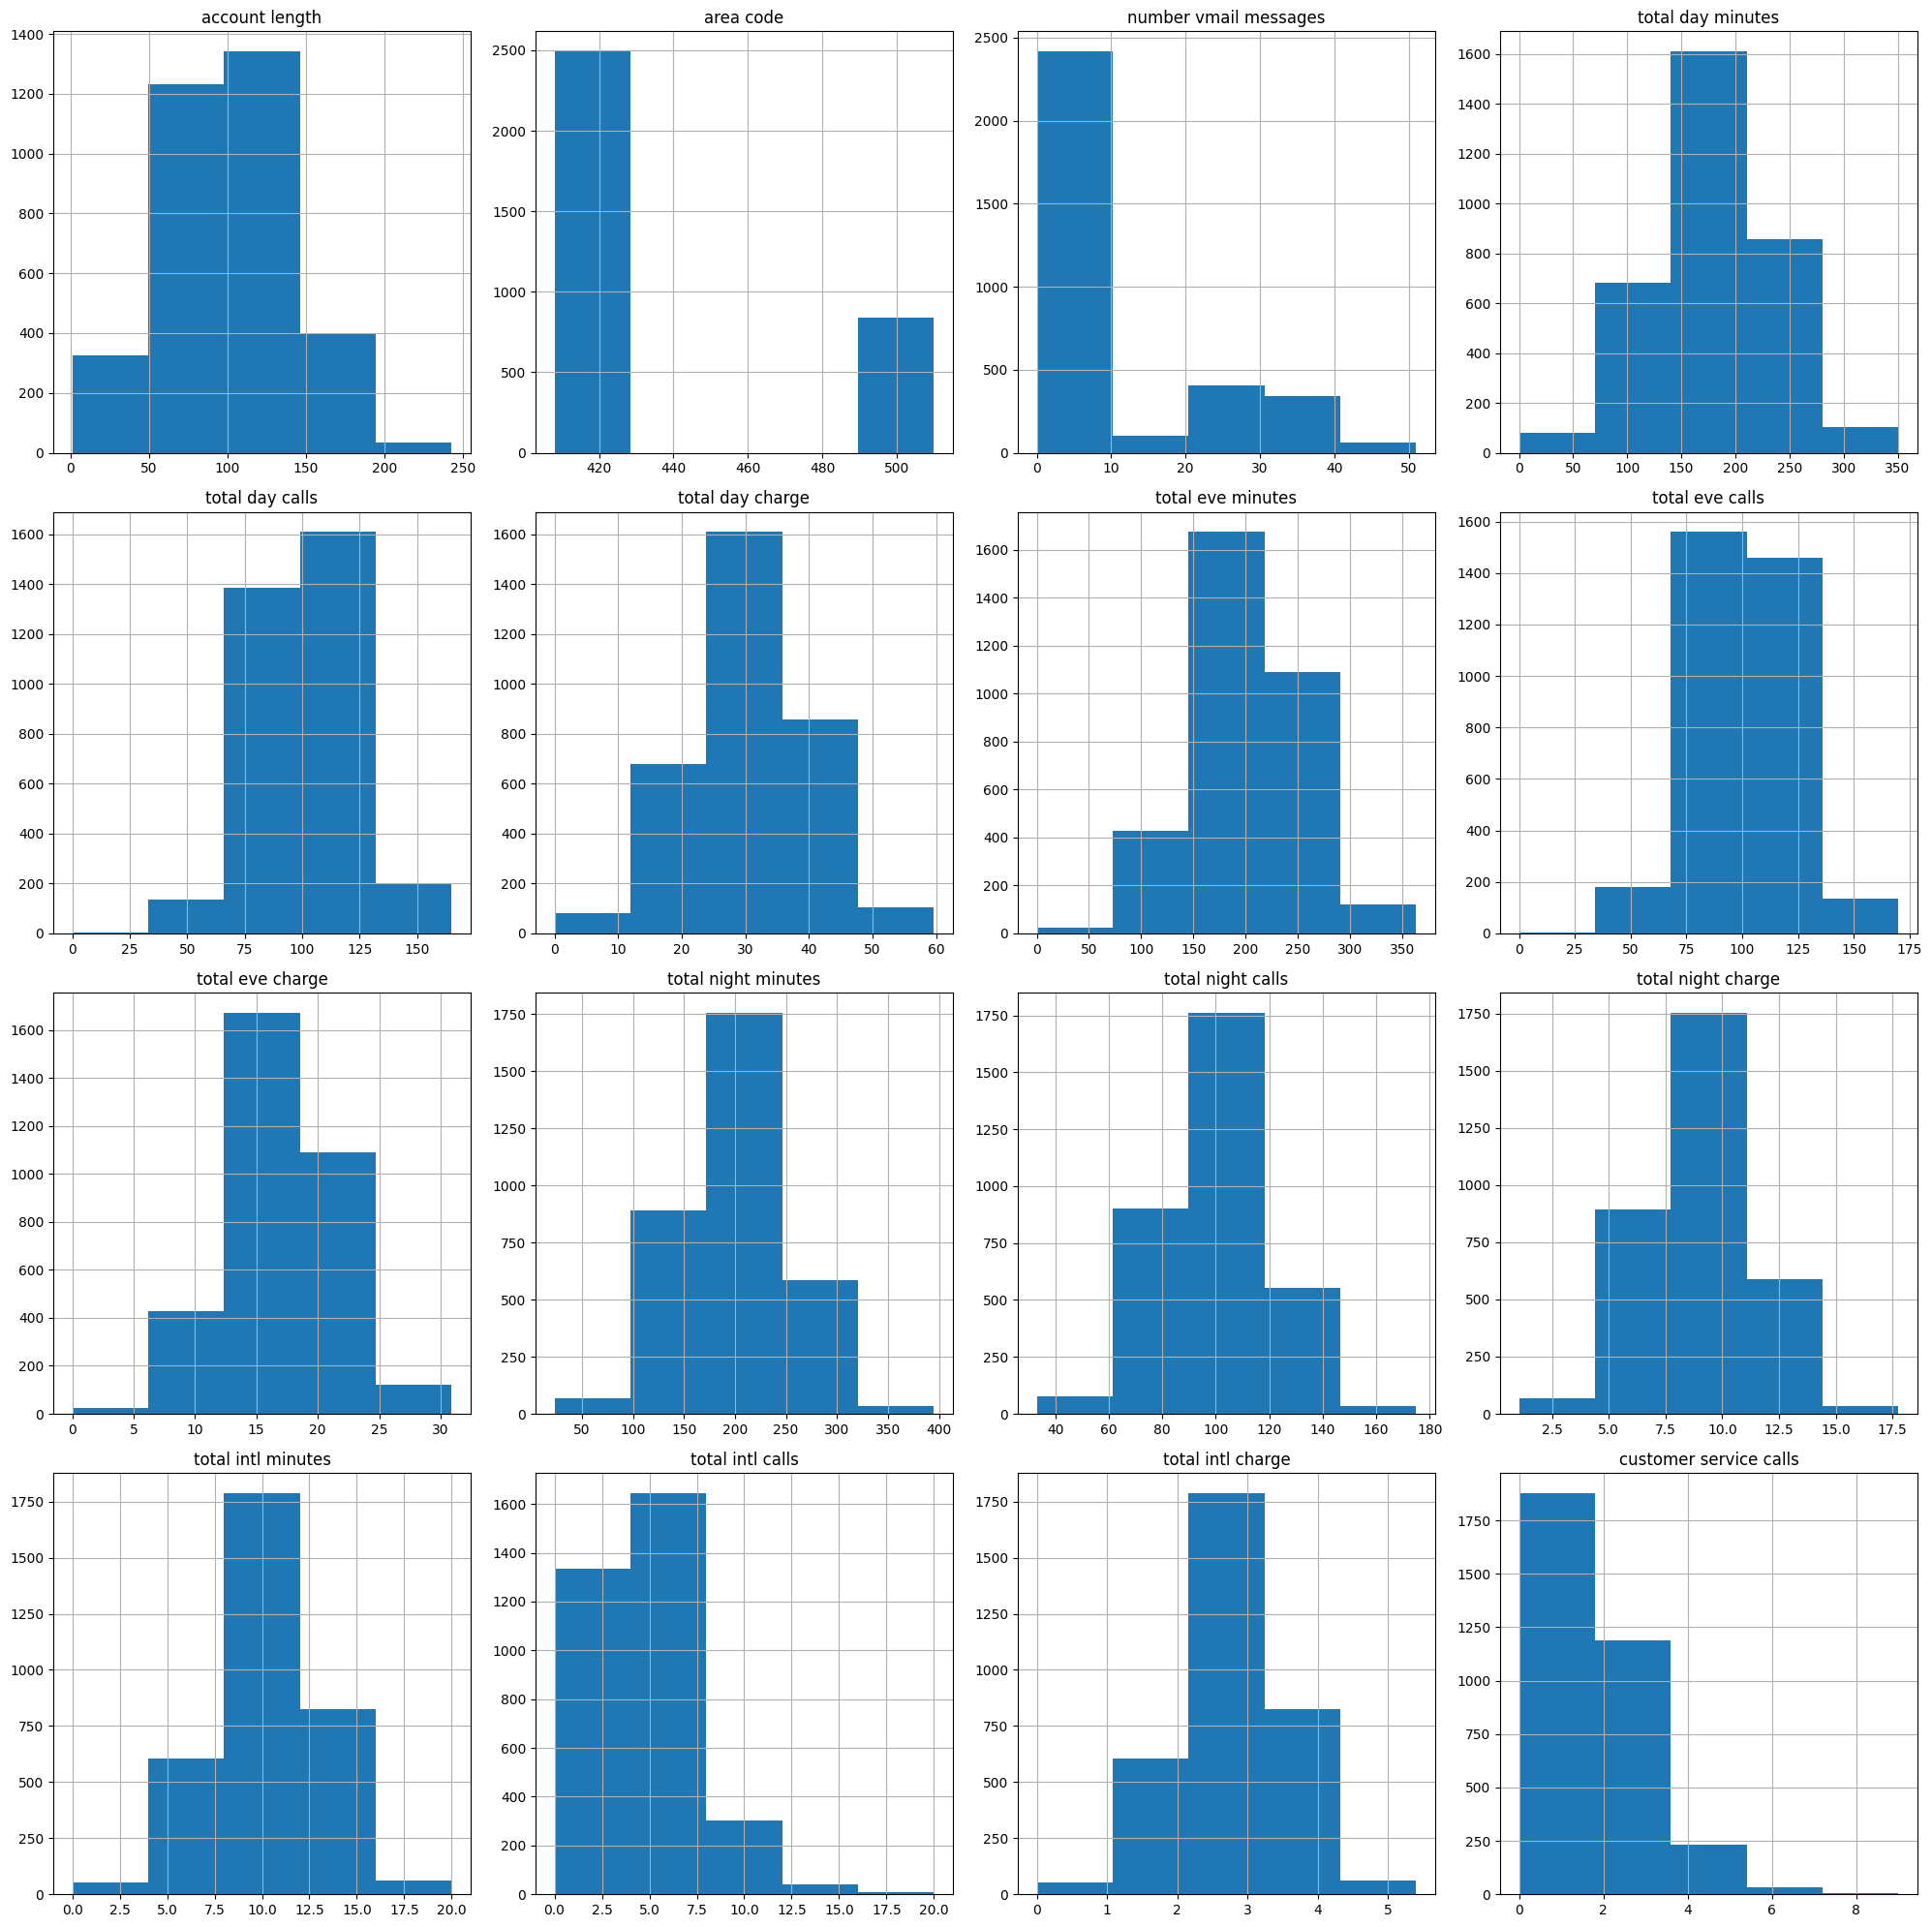

In [28]:
data.hist(figsize=(20, 20), bins=5)
plt.tight_layout()
plt.show()

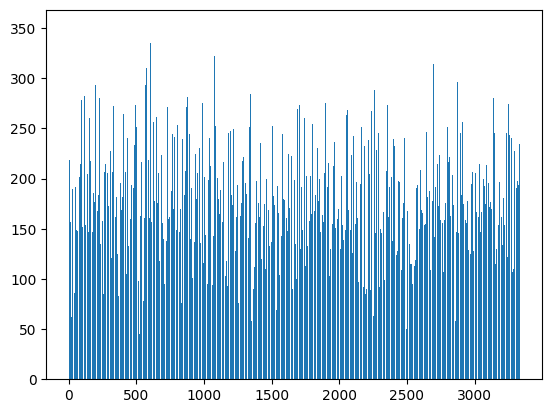

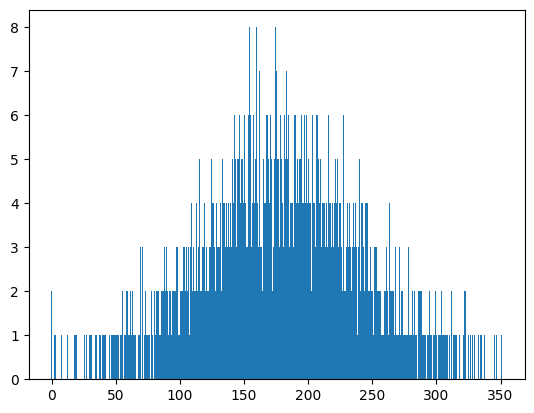

In [31]:
plt.bar(data.index, data['total day minutes'])
plt.show()

hist = data['total day minutes'].value_counts()
plt.bar(hist.index, hist)
plt.show()

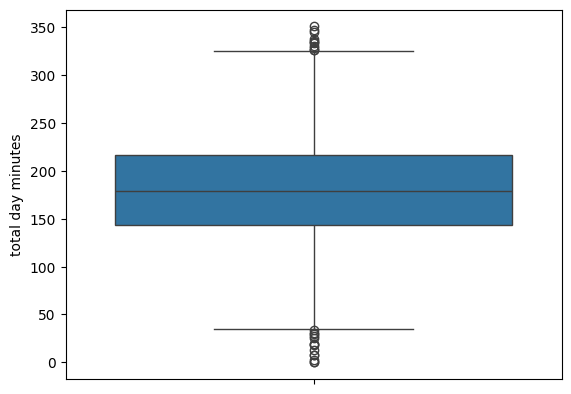

In [32]:
sns.boxplot(data['total day minutes']);

/tmp/ipykernel_9850/1775282986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='state',


<Axes: xlabel='total day minutes', ylabel='state'>

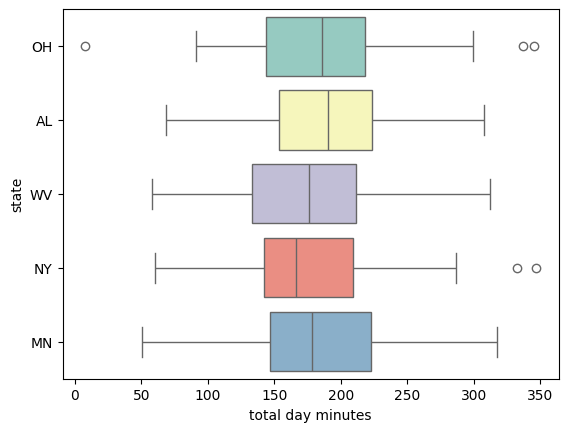

In [39]:
top_data = data[['state', 'total day minutes']]
top_data = top_data.groupby('state').sum()
top_data = top_data.sort_values('total day minutes', ascending=False)
top_data = top_data[:5].index.values
sns.boxplot(y='state',
            x='total day minutes',
            data=data[data.state.isin(top_data)], palette='Set3')

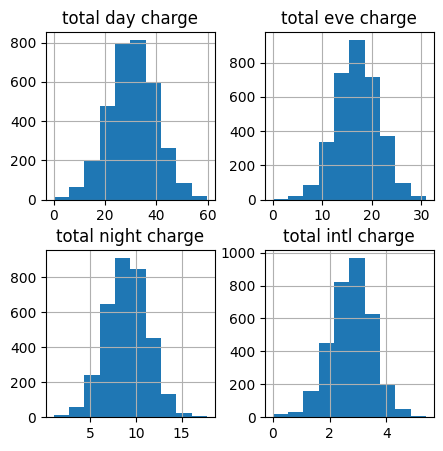

In [41]:
feats = [f for f in data.columns if 'charge' in f]
feats
data[feats].hist(figsize=(5,5));

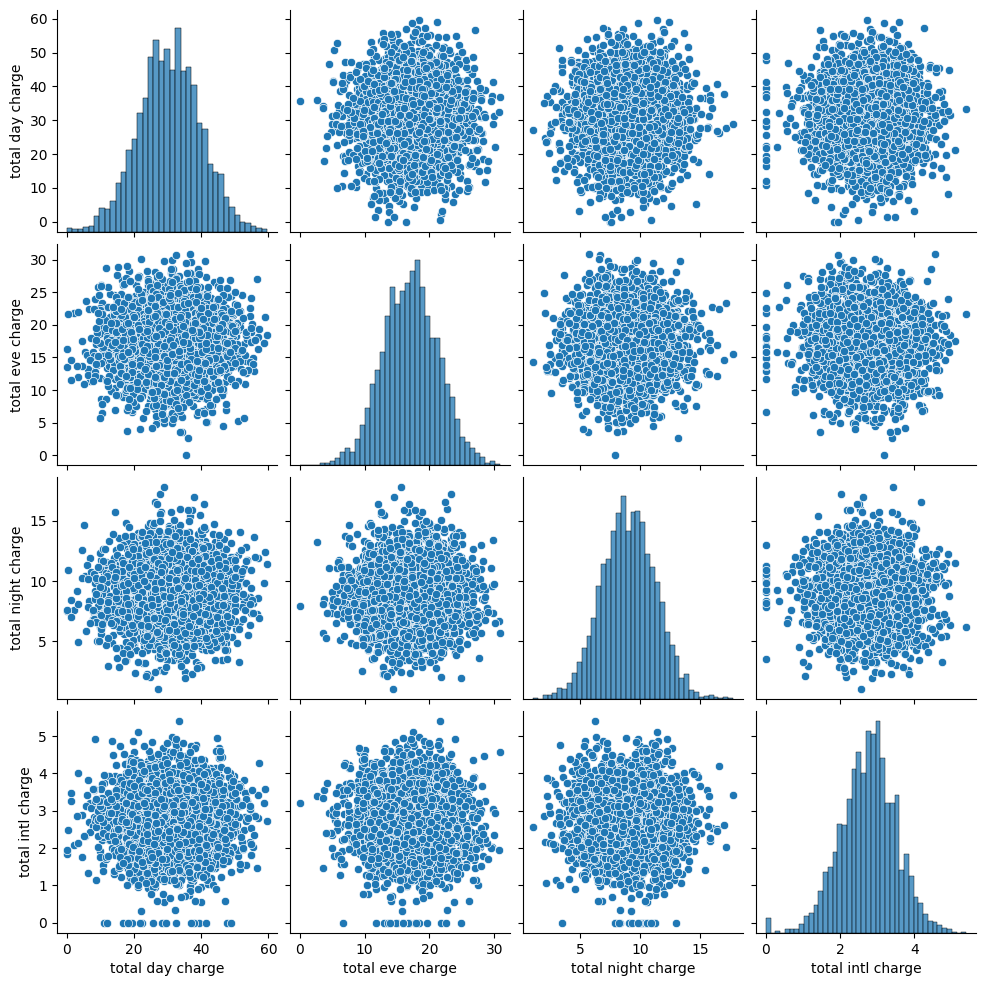

In [42]:
sns.pairplot(data[feats])

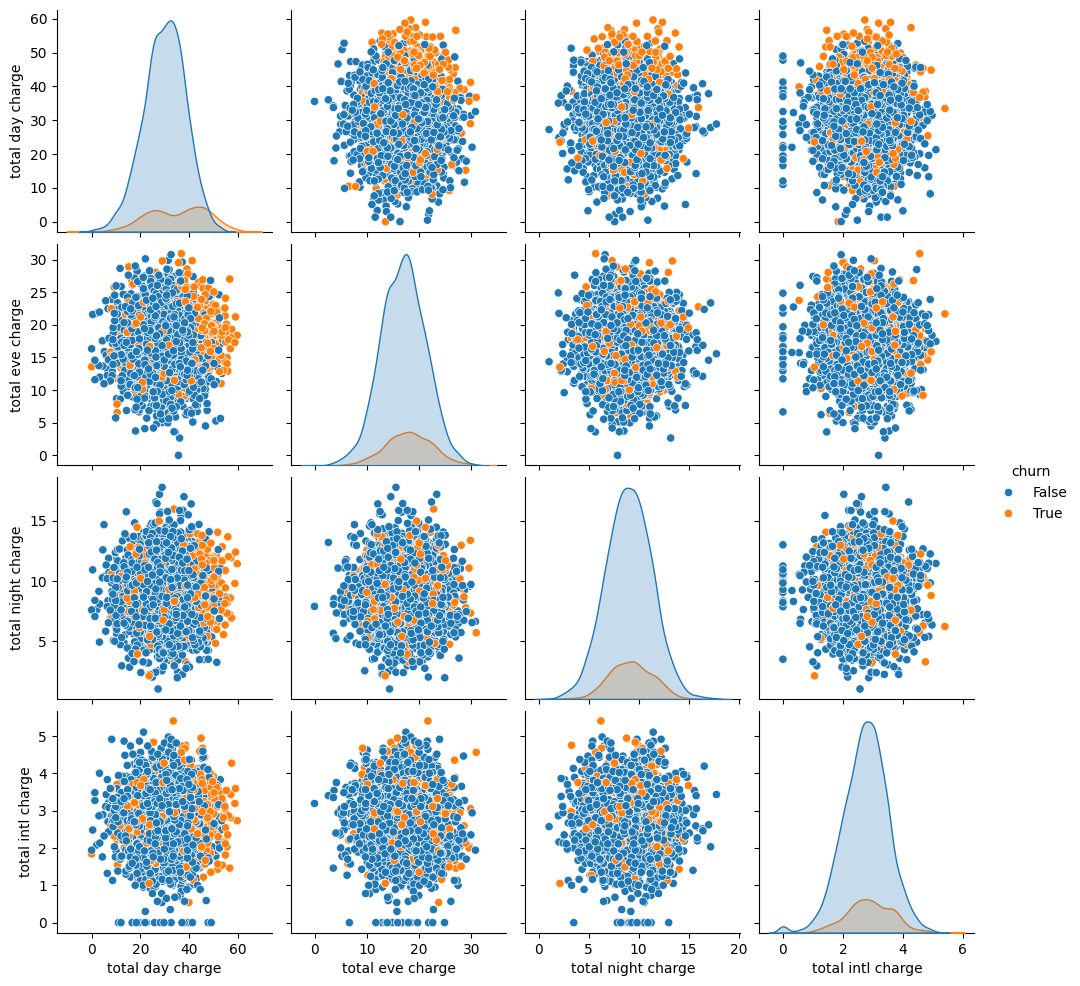

In [44]:
sns.pairplot(data[feats + ['churn']], hue='churn');

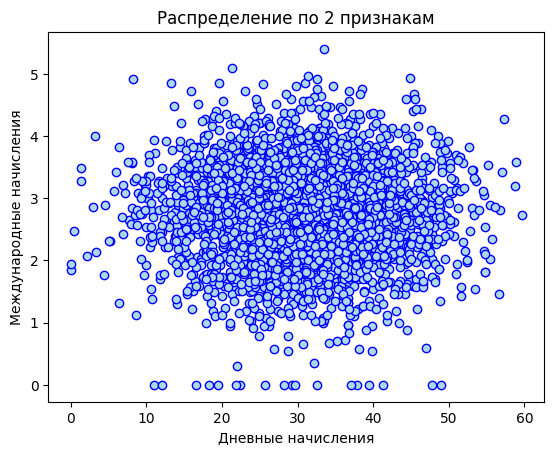

In [45]:
plt.scatter(data['total day charge'], data['total intl charge'],
            color='lightblue', edgecolors='blue')
plt.xlabel('Дневные начисления')
plt.ylabel('Международные начисления')
plt.title('Распределение по 2 признакам');

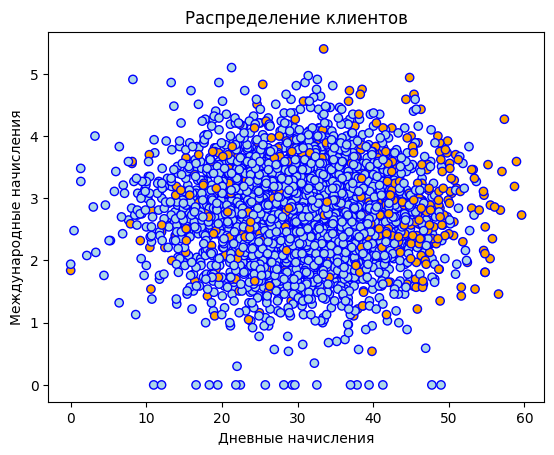

In [46]:
c = data['churn'].map({False: 'lightblue', True: 'orange'})
plt.scatter(data['total day charge'], data['total intl charge'],
            color=c, edgecolors='blue')
plt.xlabel('Дневные начисления')
plt.ylabel('Международные начисления')
plt.title('Распределение клиентов');

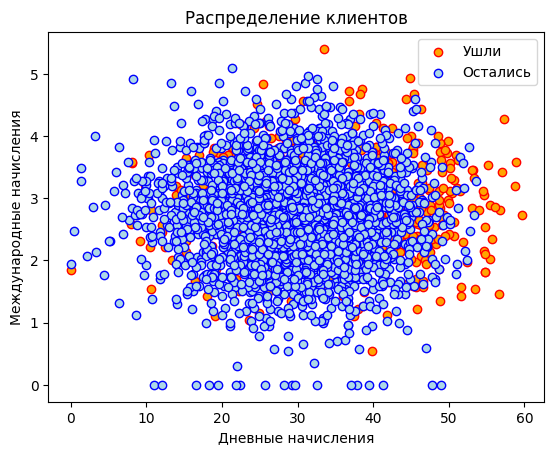

In [47]:
data_churn = data[data['churn']]

data_loyal = data[~data['churn']]

plt.scatter(data_churn['total day charge'],
            data_churn['total intl charge'],
            color='orange',
            edgecolor='red',
            label='Ушли')

plt.scatter(data_loyal['total day charge'],
            data_loyal['total intl charge'],
            color='lightblue',
            edgecolor='blue',
            label='Остались')

plt.xlabel('Дневные начисления')
plt.ylabel('Международные начисления')
plt.title('Распределение клиентов')
plt.legend()
plt.show()

In [51]:
data.corr(numeric_only=True)

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
account length,1.000000,-0.012463,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796,0.016541
area code,-0.012463,1.000000,-0.001994,-0.008264,-0.009646,-0.008264,0.003580,-0.011886,0.003607,-0.005825,0.016522,-0.005845,-0.018288,-0.024179,-0.018395,0.027572,0.006174
number vmail messages,-0.004628,-0.001994,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263,-0.089728
total day minutes,0.006216,-0.008264,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423,0.205151
total day calls,0.038470,-0.009646,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942,0.018459
total day charge,0.006214,-0.008264,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427,0.205151
total eve minutes,-0.006757,0.003580,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985,0.092796
total eve calls,0.019260,-0.011886,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423,0.009233
total eve charge,-0.006745,0.003607,0.017578,0.007029,-0.021449,0.007036,1.000000,-0.011423,1.000000,-0.012592,0.007596,-0.012601,-0.011043,0.002541,-0.011074,-0.012987,0.092786
total night minutes,-0.008955,-0.005825,0.007681,0.004323,0.022938,0.004324,-0.012584,-0.002093,-0.012592,1.000000,0.011204,0.999999,-0.015207,-0.012353,-0.015180,-0.009288,0.035493


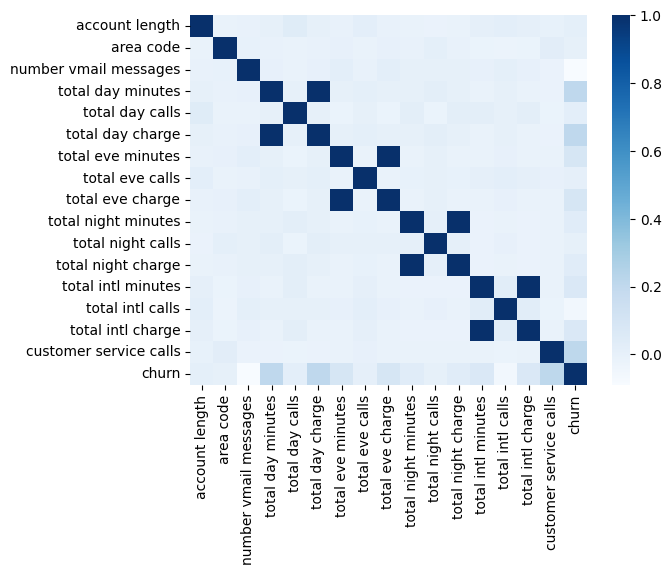

In [52]:
sns.heatmap(data.corr(numeric_only=True), cmap=plt.cm.Blues);